# Zajęcia 1. Onboarding: środowisko i pierwsze spojrzenie na dane

Dziś upewnimy się, że Twoje środowisko działa, i poznamy zbiór danych, z którym będziemy pracować na obu spotkaniach onboardingowych. Kolejność: środowisko, wczytanie danych, ich struktura i jakość, EDA z obserwacjami i zapis pracy w repozytorium.

**WAŻNE:** na razie nie czyścimy danych, nie dzielimy ich na zbiór treningowy i testowy i nie budujemy modelu. 
Tto wszystko na kolejne zajęcia. Jeśli coś w danych wyda Ci się podejrzane, zanotuj to (komentarz albo komórka markdown), ale niczego nie poprawiaj.

**Na koniec zajęć masz mieć:**

- notebook, który przechodzi bez błędów od pierwszej do ostatniej komórki,
- uzupełnione wszystkie pola *TODO: Twoja odpowiedź*,
- commit `cp1: eda` z notebookiem i raportem `env_report.json`, widoczny w Twoim repozytorium.

Jedna zasada na dziś: samo „działa” albo „widać w danych” nie wystarczy. Pokaż to wynikiem komórki.

`TODO` oznacza miejsce na Twoją pracę: kod albo odpowiedź. W polach na odpowiedź zastąp tekst w nawiasie własnymi słowami. *Wskazówki* są dla osób, które nie wiedzą, jak zacząć. Nie musisz z nich korzystać.

Całość przewidziana na ok. 60–70 minut.

## 1. Czy pracuję w dobrym środowisku?

Sprawdź, czy notebook działa w środowisku `asi-ml`, a nie w innym Pythonie z Twojego komputera. Uruchom komórkę i porównaj wynik z oczekiwaniami: Python 3.11, środowisko `asi-ml`, obie biblioteki zaimportowane.

In [38]:
import importlib
import os
import sys
from pathlib import Path

EXPECTED_ENV = "asi-ml"
EXPECTED_PYTHON = (3, 11)

env_name = Path(sys.prefix).name
conda_env = os.environ.get("CONDA_DEFAULT_ENV", "(nie ustawiono)")
interpreter = sys.executable.replace(str(Path.home()), "~")

print("Python:            ", sys.version.split()[0])
print("Interpreter:       ", interpreter)
print("Środowisko:        ", env_name)
print("CONDA_DEFAULT_ENV: ", conda_env)

problems = []
if sys.version_info[:2] != EXPECTED_PYTHON:
    problems.append(f"oczekiwany Python 3.11, a działa {sys.version_info.major}.{sys.version_info.minor}")
if EXPECTED_ENV not in (env_name, conda_env):
    problems.append(f"notebook nie działa w środowisku {EXPECTED_ENV!r}")

for module_name in ["pandas", "matplotlib"]:
    label = module_name + ":"
    try:
        module = importlib.import_module(module_name)
        print(f"{label:<20}{module.__version__}")
    except ImportError:
        problems.append(f"brakuje biblioteki {module_name}")

if problems:
    print("\nUWAGA: " + "; ".join(problems) + ".")
    print("Wybierz kernel „Python (asi-ml)” w prawym górnym rogu notebooka.")
    print("Jeśli to nie pomoże, wróć do instrukcji check_env.py w README albo przejdź na ścieżkę zapasową (Codespaces).")
else:
    print("\nŚrodowisko wygląda poprawnie. Możesz iść dalej.")

Python:             3.11.16
Interpreter:        /opt/conda/envs/asi-ml/bin/python
Środowisko:         asi-ml
CONDA_DEFAULT_ENV:  asi-ml
pandas:             3.0.6
matplotlib:         3.11.2

Środowisko wygląda poprawnie. Możesz iść dalej.


Jeśli widzisz **UWAGA**, zatrzymaj się i najpierw napraw środowisko. Zły kernel to najczęstszy powód sytuacji „u mnie działa, a u Ciebie nie”.

## 2. Importy i konfiguracja

Biblioteki i ustawienia są w jednej komórce. O tym, skąd pochodzą dane, decyduje wyłącznie `DATA_URL`. Kod i nazwy zmiennych są po angielsku, instrukcje po polsku.

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# Adres danych ustala ćwiczeniowiec. Nie zastępuj go ścieżką do pliku na swoim dysku.
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Wyswietlaj w tabelach wszystkie kolumny i dłuższe teksty.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

## 3. Wczytanie danych

Pracujemy na przykładowym zbiorze **IBM Telco Customer Churn**. Funkcja poniżej pobiera go spod `DATA_URL` do `df`. Jeśli pobieranie się nie uda, komunikat podpowie, co sprawdzić.

Komórka zapisuje też kopię danych zaraz po wczytaniu. Checkpoint na końcu porówna z nią `df`. Muszą być identyczne. Jeśli chcesz coś przetestować na zmienionych danych, rób to na kopii (`df.copy()`), a nie na `df`.

In [40]:
def load_data(url):
    """Wczytuje zbiór danych z podanego adresu."""
    try:
        return pd.read_csv(url)
    except Exception as error:
        raise RuntimeError(
            "Nie udało się wczytać danych z DATA_URL. Sprawdź połączenie z internetem "
            "i to, czy adres w sekcji 2 nie został zmieniony. Jeśli problem się powtarza, "
            "zgłoś go w kolejce pomocy i wklej ten komunikat."
        ) from error


df = load_data(DATA_URL)

# Kopia danych zaraz po wczytaniu. Checkpoint w sekcji 9 porówna z nią df. Nie zmieniaj jej.
_original_df = df.copy(deep=True)

print("Dane wczytane.")

Dane wczytane.


Skąd pochodzą te dane? I dlaczego w projekcie nie chcemy, żeby kod zależał od ścieżki do pliku na komputerze jednej osoby?

**TODO: Twoja odpowiedź** (1-2 zdania):

Pochodza one ze: DATA_URL, nie uzywamy lokalnej sciezki poniewaz taka sceizka działał by tylko w obrebie jednego komputera i mogła by sie nie uruchomic na innym

## 4. Pierwsze spojrzenie na dane (ok. 5 min)

Najpierw sprawdźmy, z czym pracujemy. Każde zadanie poniżej to jedna linia pandas, a jej wynik ma być widoczny pod komórką.

In [41]:
# TODO: ile zbiór ma wierszy i kolumn?
# Wskazówka: DataFrame ma atrybut, który zwraca obie liczby naraz.
df.shape

(7043, 21)

In [42]:
# TODO: pokaż pierwsze 5 wierszy.
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
# TODO: pokaż nazwy kolumn.
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [44]:
# TODO: sprawdź typ (dtype) każdej kolumny.
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [45]:
# TODO: pokaż podsumowanie DataFrame'u: typy, liczbę niepustych wartości i zużycie pamięci.
# Wskazówka: wystarczy jedna metoda bez argumentów.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Zanim pójdziesz dalej: czy umiesz powiedzieć, **co opisuje jeden wiersz danych** w tym zbiorze i **co jest targetem**? Jeśli nie, wróć do wyników powyżej. Odpowiedź zapiszesz w sekcji 8.

## 5. Jakość danych

Czy tym danym można ufać? Niczego tu nie poprawiamy ani nie usuwamy, tylko zbieramy fakty.

### 5.1 Braki danych

Ile braków widzi pandas w każdej kolumnie?

In [46]:
# TODO: policz braki w każdej kolumnie.
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**TODO: Twoja odpowiedź** (jedno zdanie): co ten wynik mówi o brakach w danych?

Nie ma zadnych braków w zadnej kolumniej 

### 5.2 Duplikaty

Czy któryś wiersz występuje w zbiorze więcej niż raz?

In [47]:
# TODO: policz wiersze, które są dokładnymi kopiami innych wierszy.
df.duplicated().sum()

np.int64(0)

### 5.3 Identyfikator

Która kolumna jednoznacznie wskazuje rekord? Znajdź ją i sprawdź, czy jej wartości naprawdę się nie powtarzają.

In [48]:
# TODO: wpisz nazwę kolumny, która Twoim zdaniem identyfikuje rekord.
id_column = "customerID"

# TODO: sprawdź, czy wartości w tej kolumnie są unikalne (jedna linia kodu).
df[id_column].is_unique

True

**TODO: Twoja odpowiedź** (jedno zdanie): co by to znaczyło dla analizy, gdyby identyfikator nie był unikalny?

oznaczał by powtarzajace sie rekordy i pojawiały by sie bledne wyniki analizy

### 5.4 Liczba unikalnych wartości

Ile różnych wartości ma każda kolumna?

In [49]:
# TODO: policz unikalne wartości w każdej kolumnie i posortuj wynik rosnąco.
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

**TODO: Twoja odpowiedź:** które kolumny mają tylko dwie wartości, które kilka, a które bardzo wiele? Czy któraś ma prawie tyle wartości, ile jest wierszy i co to może znaczyć?

Kolumny z dwoma wartosciami:gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Churn
Kolumny z kilkoma wartosciami: MultipleLines,TechSupport,StreamingTVk,OnlineBackup,DeviceProtection,StreamingMovies,Contract,OnlineSecurity,InternetService,PaymentMethod     
Kolumny z większa liczba wartosci to: tenure,MonthlyCharges,TotalCharges,customerID
Tak customerID ma 7043 wiersze co oznacza ze jest on kluczem identyfikujacym klienta

### 5.5 Czy typy pasują do znaczenia kolumn?

Helper poniżej zestawia typ każdej kolumny z kilkoma przykładowymi wartościami. Łatwiej wtedy porównać to, jak kolumnę widzi pandas, z tym, co ona naprawdę opisuje. Tekst jest pokazany w cudzysłowie.

In [50]:
def show_types_with_examples(data, n_examples=3):
    """Zestawia typ każdej kolumny z kilkoma przykładowymi wartościami."""
    rows = []
    for column in data.columns:
        examples = data[column].dropna().unique()[:n_examples]
        formatted = [repr(value) if isinstance(value, str) else str(value) for value in examples]
        rows.append(
            {
                "kolumna": column,
                "typ w pandas": str(data[column].dtype),
                "przykładowe wartości": ", ".join(formatted),
            }
        )
    return pd.DataFrame(rows)


show_types_with_examples(df)

,kolumna,typ w pandas,przykładowe wartości
0,customerID,str,"'7590-VHVEG', '5575-GNVDE', '3668-QPYBK'"
1,gender,str,"'Female', 'Male'"
2,SeniorCitizen,int64,"0, 1"
3,Partner,str,"'Yes', 'No'"
4,Dependents,str,"'No', 'Yes'"
5,tenure,int64,"1, 34, 2"
6,PhoneService,str,"'No', 'Yes'"
7,MultipleLines,str,"'No phone service', 'No', 'Yes'"
8,InternetService,str,"'DSL', 'Fiber optic', 'No'"
9,OnlineSecurity,str,"'No', 'Yes', 'No internet service'"


Przejrzyj tabelę kolumna po kolumnie.

**TODO: Twoja odpowiedź** (podaj nazwy kolumn i to, na jakiej podstawie tak uważasz):

1. Czy typ każdej kolumny pasuje do tego, co ta kolumna opisuje?

   Nie, Totalcharges jest typu str a ma wartosci liczbowe, SeniorCitizen jest typu int64 a oznacza kategorie tylko 1 albo 0

2. Czy któraś kolumna wygląda na liczbową, a pandas traktuje ją inaczej?

   TotalCharges to kolumna liczbowa a pandas widzi ja jako str

3. A odwrotnie, czy jest kolumna zapisana jako liczba, która tak naprawdę oznacza kategorię?

   SeniorCitizen jest jako int64 a ma tylko wartosci 0 i 1

### 5.6 Sprawdź swoje podejrzenie

Jeśli w 5.5 znalazła się kolumna, która wygląda na liczbową, a pandas jej tak nie traktuje, sprawdź dlaczego. Pomoże w tym helper: pokazuje wartości, których nie da się odczytać jako liczby. Niczego nie zmienia w danych.

*Wskazówka:* jeśli nie wiesz, którą kolumnę sprawdzić, przetestuj helperem kolumny tekstowe, które w 5.4 miały bardzo dużo różnych wartości.

In [51]:
def show_non_numeric_values(data, column, max_examples=5):
    """Pokazuje wartości kolumny, których nie da się odczytać jako liczby. Nie zmienia danych."""
    if column is None:
        raise ValueError('Uzupełnij TODO: wpisz nazwę kolumny w cudzysłowie, np. column_to_check = "nazwa_kolumny".')
    if column not in data.columns:
        raise ValueError(f"Nie ma kolumny {column!r}. Sprawdź pisownię bo wielkość liter ma znaczenie.")
    values = data[column]
    as_numbers = pd.to_numeric(values, errors="coerce")
    not_numeric = values[as_numbers.isna() & values.notna()]
    print(f"Kolumna {column!r}: {len(not_numeric)} z {len(values)} wartości nie da się odczytać jako liczby.")
    if len(not_numeric) > 0:
        print("Przykłady (w cudzysłowie, żeby było widać dokładną zawartość):")
        for value in not_numeric.drop_duplicates().head(max_examples):
            print("   ", repr(value))


# TODO: wpisz nazwę kolumny wskazanej w 5.5.
column_to_check = "TotalCharges"

show_non_numeric_values(df, column_to_check)

Kolumna 'TotalCharges': 11 z 7043 wartości nie da się odczytać jako liczby.
Przykłady (w cudzysłowie, żeby było widać dokładną zawartość):
    ' '


**TODO: Twoja odpowiedź:**

1. Dlaczego pandas nie traktuje tej kolumny jako liczbowej?

   W totalcharges mamy puste wartosci zapisane jako ' ' których nie da sie odczytac jako liczby

2. Ilu wierszy to dotyczy?

   11

3. Wróć do wyniku z 5.1. Czy „brak braków” był całą prawdą?

   nie było cała prawda nie został wykryty własnie ten przypadek

**Nie naprawiaj tego teraz.** Co zrobić z tymi wartościami, zdecydujemy na kolejnych zajęciach. Dziś wystarczy dobrze opisać problem.

## 6. Zmienna docelowa

Jak rozkładają się wartości targetu? Jego nazwę trzymamy w jednej zmiennej, żeby nie wpisywać jej ręcznie w wielu miejscach.

In [52]:
TARGET = "Churn"

In [53]:
# TODO: policz, ile wierszy ma każda wartość targetu.
df[TARGET].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [54]:
# TODO: policz proporcje klas (ułamki, które sumują się do 1).
# Wskazówka: metoda z poprzedniej komórki ma parametr, który zamienia liczności na proporcje.
df[TARGET].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

<Axes: xlabel='Churn'>

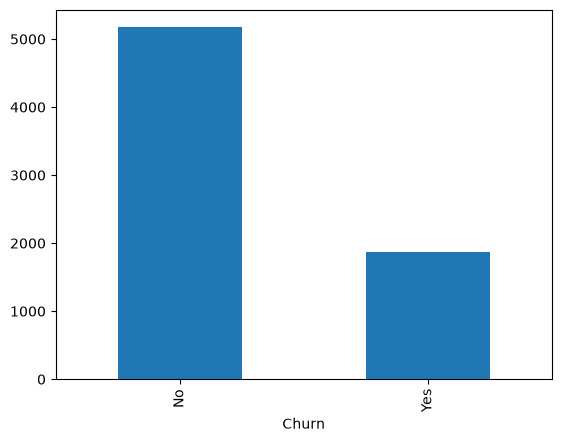

In [55]:
# TODO: narysuj wykres słupkowy liczności klas.
# Wskazówka: wynik value_counts() ma własną metodę .plot(kind="bar").
df[TARGET].value_counts().plot(kind="bar")

**TODO: Twoja odpowiedź:**

1. Czy klasy są zbalansowane? Podaj proporcje.

   nie sa zbalansowane, około 70% dla nie i 30% dla tak

2. Załóżmy, że „model” zawsze przewiduje najczęstszą klasę. W jakim odsetku przypadków miałby rację? Co to mówi o tym, jak ostrożnie trzeba będzie czytać accuracy?

   ponieważ model byłby poprawny w około 70% przypadków, co było by mylące bo mozna go uznać za poprawny pomimo tego że nie rozpoznaje żadnej klasy tak

## 7. Małe EDA

Teraz poszukajmy pierwszych zależności między cechami a targetem. Zrobisz dwie eksploracje. Jedną dla kolumny liczbowej, drugą dla kategorycznej. Kolumny wybierasz samodzielnie.

Wykres bez interpretacji to jeszcze nie analiza, więc pod każdym zapisz jedno zdanie obserwacji. Opisz tylko to, co widać w danych: najlepiej z liczbą albo porównaniem. Na tym etapie nie wiemy, czy jedna rzecz powoduje drugą.

Przykład z innej dziedziny: zamiast „Deszcz powoduje korki” napisz „W danych w dni deszczowe przejazd trwa średnio o ok. 20% dłużej”.

Dwa helpery poniżej rysują wykres wybranej kolumny w podziale na target, żeby czas szedł na interpretację, a nie na formatowanie wykresów. Uruchom komórkę. Sama definicja jeszcze niczego nie rysuje.

In [56]:
def _check_column_choice(data, column, target):
    """Sprawdza, czy wybraną kolumnę da się porównać z targetem."""
    if column is None:
        raise ValueError("Uzupełnij TODO: wpisz nazwę wybranej kolumny w cudzysłowie.")
    if column not in data.columns:
        raise ValueError(f"Nie ma kolumny {column!r}. Sprawdź pisownię bo wielkość liter ma znaczenie.")
    if column == target:
        raise ValueError("Wybierz kolumnę inną niż target. To właśnie z targetem ją porównujemy.")


def plot_numeric_by_target(data, column, target):
    """Porównuje rozkład kolumny liczbowej w klasach targetu."""
    _check_column_choice(data, column, target)
    if not pd.api.types.is_numeric_dtype(data[column]):
        raise ValueError(
            f"Kolumna {column!r} ma w pandas typ {data[column].dtype}, więc helper nie narysuje jej rozkładu. "
            "Jeśli ta kolumna powinna być liczbowa, wróć do swoich obserwacji z sekcji 5, a tutaj wybierz inną."
        )
    _, ax = plt.subplots(figsize=(8, 4))
    for label, group in data.groupby(target):
        ax.hist(group[column], bins=30, alpha=0.5, density=True, label=f"{target} = {label}")
    ax.set_title(f"Rozkład {column} w podziale na {target}")
    ax.set_xlabel(column)
    ax.set_ylabel("gęstość (osobno dla każdej klasy)")
    ax.legend()
    plt.show()
    print("Mediana w każdej klasie:")
    print(data.groupby(target)[column].median().to_string())


def plot_category_by_target(data, column, target, positive_label="Yes", max_categories=20):
    """Pokazuje, jaki odsetek wierszy w każdej kategorii ma target równy positive_label."""
    _check_column_choice(data, column, target)
    n_categories = data[column].nunique()
    if n_categories > max_categories:
        raise ValueError(
            f"Kolumna {column!r} ma {n_categories} różnych wartości czyli raczej nie jest kategoria. "
            "Wybierz kolumnę z kilkoma wartościami (pomoże wynik z 5.4)."
        )
    is_positive = data[target] == positive_label
    rate_label = f"odsetek {target} = {positive_label}"
    summary = pd.DataFrame(
        {
            "liczba wierszy": data.groupby(column).size(),
            rate_label: is_positive.groupby(data[column]).mean().round(3),
        }
    ).sort_values(rate_label)
    overall_rate = is_positive.mean()
    _, ax = plt.subplots(figsize=(8, 1.5 + 0.5 * n_categories))
    ax.barh(summary.index.astype(str), summary[rate_label])
    ax.axvline(overall_rate, color="gray", linestyle="--", label=f"cały zbiór: {overall_rate:.1%}")
    ax.set_title(f"{rate_label} w kategoriach kolumny {column}")
    ax.set_xlabel(rate_label)
    ax.legend()
    plt.show()
    return summary.sort_values(rate_label, ascending=False)

### 7.1 Kolumna liczbowa

Wybierz kolumnę, która opisuje jakąś wielkość liczbową. Nie kieruj się wyłącznie typem wyświetlanym przez pandas i przypomnij sobie swoje obserwacje z sekcji 5.

Oś Y pokazuje gęstość osobno dla każdej klasy, żeby mniej liczna klasa nie zginęła na wykresie.

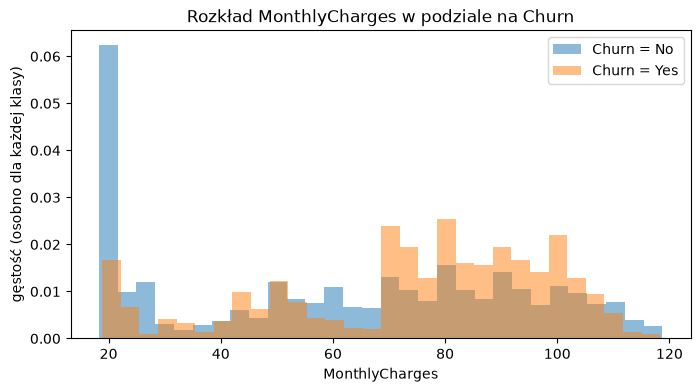

Mediana w każdej klasie:
Churn
No     64.425
Yes    79.650


In [57]:
# TODO: wpisz nazwę wybranej kolumny liczbowej.
numeric_column = "MonthlyCharges"

plot_numeric_by_target(df, numeric_column, TARGET)

**TODO: Obserwacja** (jedno zdanie zaczynające się od „W danych widzimy, że…”):

widzimy ze klienci którzy zrezygnowali maja wyższa mediane miesięcznych opłat ok 80%, Klienci którzy pozostali mają ok 65%

### 7.2 Kolumna kategoryczna

Wybierz kolumnę, która opisuje kategorię. Przerywana linia to odsetek dla całego zbioru, więc łatwo porównać z nim każdą kategorię. Pod wykresem pojawi się też tabela z liczbami.

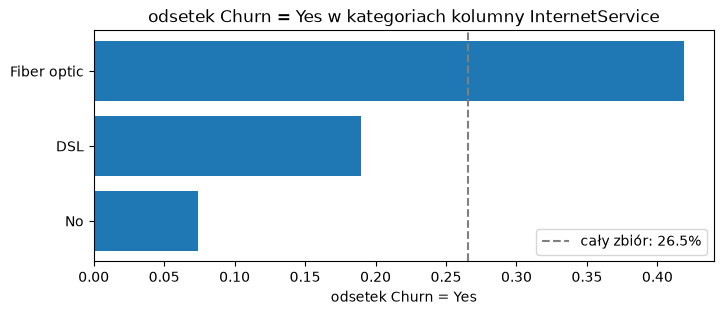

,liczba wierszy,odsetek Churn = Yes
InternetService,,
Fiber optic,3096,0.419
DSL,2421,0.190
No,1526,0.074


In [58]:
# TODO: wpisz nazwę wybranej kolumny kategorycznej.
categorical_column = "InternetService"

plot_category_by_target(df, categorical_column, TARGET)

**TODO: Obserwacja** (jedno zdanie zaczynające się od „W danych widzimy, że…”):

w danych widzimy ze klienci swiatlowodu maja najwiekszy procent rezygnacji z uslug 41% natomiast klienci DSL tylko 19%, a klienci bez internetu ok 7%

### 7.3 Dla chętnych

Jeśli masz jeszcze czas, zbadaj kolejną kolumnę dowolnym z helperów i dopisz obserwację pod wykresem.

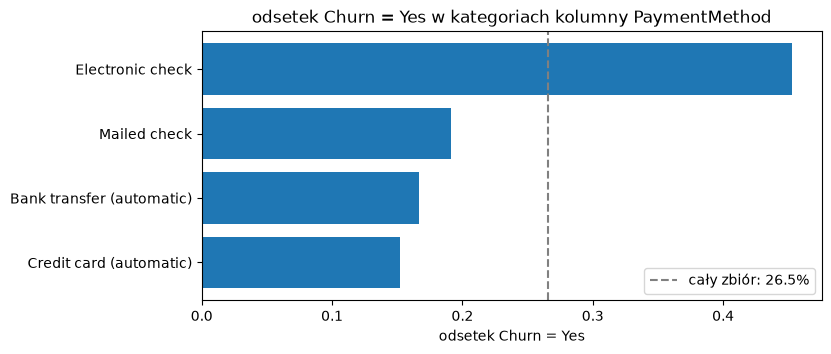

,liczba wierszy,odsetek Churn = Yes
PaymentMethod,,
Electronic check,2365,0.453
Mailed check,1612,0.191
Bank transfer (automatic),1544,0.167
Credit card (automatic),1522,0.152


In [59]:
plot_category_by_target(df, "PaymentMethod", TARGET)
# TODO (opcjonalnie): wywołaj jeden z helperów dla kolejnej kolumny.

**Obserwacja (opcjonalnie):** W danych widzimy, że najwiecej rezygnacji wystepoje pry electronic check ok 45%, przy mailed check tylko 19%, a przy automatycznyk platnosciach ok 15%-16% dla kart kredytowych i bankowych przelewów

## 8. Pytania kontrolne (ok. 5 min)

Odpowiadaj krótko i opieraj się na wynikach z tego notebooka. Tam, gdzie się da, podaj liczbę albo nazwę kolumny.

**TODO: Twoje odpowiedzi:**

1. Co reprezentuje jeden wiersz tego zbioru?

   reprezentuje on jednego klienta firmy telekomunikacyjnej i informacje o jego usługach umowie i opłatach

2. Co jest targetem i co oznaczają jego wartości?

   targetem jest kolumna Churn yes - rezygnacja z usług , No - klient dalej korzysta z usług 

3. Która kolumna zwróciła Twoją uwagę pod względem typu? Który wynik z notebooka to pokazuje?

   totalcharges pandas traktuja ja jako str mimo ze zawiera wartosci liczbowe, sprawdzenie pokazalo ze zawierał on 11 pustych wartosci liczbowych

4. Czy jest kolumna, której raczej nie chcielibyśmy używać jako predyktora? Dlaczego?

   customerId ponieważ jest to klucz głowny i nie opiusje cech itd, jest poprostu indeksem

5. Podaj jedną obserwację z Twoich wykresów, bez słów „powoduje” i „wpływa”.

   klienci swiatłowodu rezygnuja w ok 41% przypadkow a klienci DSL ok 19% oraz klienci bez internetu tylko w 7%

6. Która z Twoich obserwacji jest najmniej pewna i co trzeba by sprawdzić, żeby bardziej jej ufać?

   prawdopodobnie obserwacja pomiedzy rodzajem platnosci i rezygnacji, bez sprawdzenia rodzaju umowy i wysokosci opat oraz jej dlgosc nie jestesmy w stanie stwierdzic czy jest ona w 100% poprawna

## 9. Checkpoint techniczny

Ta komórka sprawdza tylko to, co da się sprawdzić automatycznie: czy dane są wczytane i czy `df` wygląda dokładnie tak jak zaraz po wczytaniu. Twoich odpowiedzi nie ocenia. Jeśli pojawi się błąd, przeczytaj komunikat, który podpowiada, co poprawić.

In [60]:
EXPECTED_ROWS = 7043
EXPECTED_COLUMNS = 21
CHANGED_DF = (
    "DataFrame df został zmieniony. Na pierwszych zajęciach tylko analizujemy dane, nie usuwamy wierszy ani kolumn "
    "i nie zmieniamy wartości ani typów. Usuń kod, który zmienia df, i uruchom notebook od nowa (Restart, Run All)."
)

assert "df" in globals() and isinstance(df, pd.DataFrame), (
    "Nie ma DataFrame'u df. Uruchom komórkę wczytującą dane w sekcji 3."
)
assert "_original_df" in globals(), "Nie ma kopii danych z sekcji 3. Uruchom ponownie komórkę wczytującą dane."
assert _original_df.shape == (EXPECTED_ROWS, EXPECTED_COLUMNS), (
    f"Wczytany zbiór ma rozmiar {_original_df.shape}, a powinien mieć ({EXPECTED_ROWS}, {EXPECTED_COLUMNS}). "
    "Sprawdź, czy DATA_URL w sekcji 2 nie został zmieniony."
)

missing_columns = [column for column in _original_df.columns if column not in df.columns]
new_columns = [column for column in df.columns if column not in _original_df.columns]
assert not missing_columns and not new_columns, (
    f"{CHANGED_DF}\nUsunięte kolumny: {missing_columns}. Dodane kolumny: {new_columns}."
)
assert list(df.columns) == list(_original_df.columns), f"{CHANGED_DF}\nZmieniła się kolejność kolumn."
assert len(df) == len(_original_df), f"{CHANGED_DF}\nLiczba wierszy: była {len(_original_df)}, jest {len(df)}."

changed_types = [column for column in df.columns if df[column].dtype != _original_df[column].dtype]
assert not changed_types, f"{CHANGED_DF}\nZmieniony typ w kolumnach: {changed_types}."
assert df.index.equals(_original_df.index), (
    f"{CHANGED_DF}\nZmieniła się kolejność albo indeks wierszy, np. po sortowaniu zapisanym z powrotem do df."
)
changed_values = [column for column in df.columns if not df[column].equals(_original_df[column])]
assert not changed_values, f"{CHANGED_DF}\nZmienione wartości w kolumnach: {changed_values}."
assert df.equals(_original_df), CHANGED_DF

print("Checkpoint zaliczony: df jest identyczny z danymi wczytanymi w sekcji 3.")

Checkpoint zaliczony: df jest identyczny z danymi wczytanymi w sekcji 3.


## 10. Co już mamy, a czego jeszcze nie mamy?

**Mamy:**

- dane wczytane z jednego, wspólnego źródła;
- ich podstawowe rozpoznanie: strukturę, typy i target;
- pierwsze obserwacje poparte wynikami;
- wykryte problemy z jakością danych: opisane, ale nienaprawione.

**Nie mamy jeszcze:**

- czyszczenia danych;
- podziału na zbiór treningowy i testowy;
- przygotowania cech dla modelu (preprocessingu);
- modelu;
- punktu odniesienia (baseline'u), z którym można porównać model;
- ewaluacji.

Ostatnie pytanie: co musielibyśmy zrobić, żeby na podstawie tych danych zacząć budować model?

**TODO: Twoja odpowiedź** (kilka punktów; wrócimy do tego następnym razem):

podzeilic dane na zbior treningowy i testowy, 
oczyscic dane poprawic TotalCharges
zakodowac zmienne kategoryczne
wybrac odpowiedni model do treningu i budowy

## 11. Zapis pracy

Zostaw w repozytorium dowód swojej pracy.

1. Zapisz notebook (Ctrl+S, na Macu Cmd+S).
2. Sprawdź, czy wszystko działa od początku: w VS Code kliknij **Restart**, a potem **Run All**. Wszystkie komórki powinny przejść bez błędów, a checkpoint z sekcji 9 wypisać „Checkpoint zaliczony”. Potem zapisz notebook jeszcze raz.
3. Wyszukaj (Ctrl+F) tekst „(odpowiedź)”. Nie powinien zostać w żadnym polu na odpowiedź.
4. Zrób jeden commit z notebookiem i raportem środowiska. W terminalu, w katalogu repozytorium:

   ```bash
   git status
   git add notebooks/01_onboarding_eda.ipynb env_report.json
   git commit -m "cp1: eda"
   git push
   ```

   `git status` pokaże, które pliki się zmieniły. Jeśli git nie znajdzie `env_report.json`, wygeneruj raport ponownie skryptem `check_env.py` (instrukcja w README).

5. Otwórz repozytorium na GitHubie i sprawdź, czy najnowszy commit to `cp1: eda`. Obok commita pojawi się automatyczne sprawdzenie. Zielony znak oznacza, że notebook przeszedł test na czystej maszynie. Jeśli jest czerwony, kliknij go i przeczytaj pierwszy błąd.

Pracę na gałęziach i Pull Requesty dołożymy na kolejnych zajęciach. Dziś wystarczy commit i push.